Đang nạp mô hình AI...
AI đang tính toán nhiệt độ tương lai cho TP.HCM...


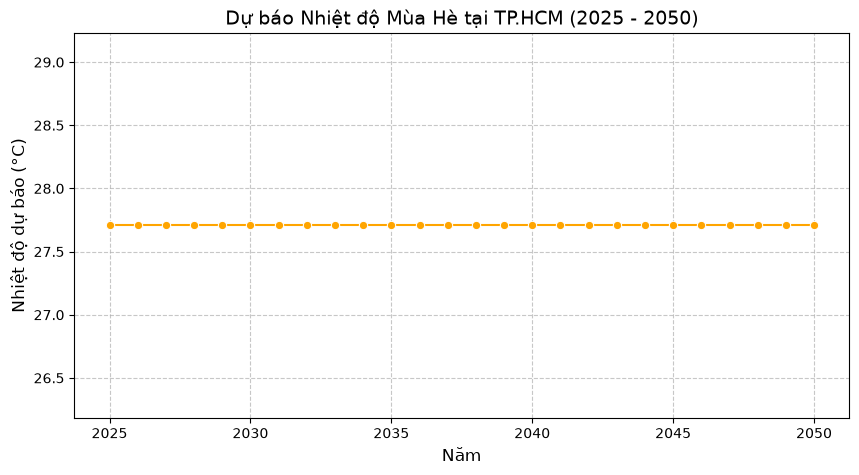

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. GỌI AI "THỨC DẬY" (Load model đã lưu)
print("Đang nạp mô hình AI...")
model = joblib.load('../model/climate_model_v1.pkl')
le_season = joblib.load('../model/season_encoder.pkl')

# 2. CHỌN MỘT ĐỊA ĐIỂM ĐỂ DỰ BÁO (Ví dụ: TP. Hồ Chí Minh)
# Tọa độ TP.HCM: Vĩ độ (Lat) = 10.82, Kinh độ (Lon) = 106.63
lat_hcm = 10.82
lon_hcm = 106.63

# Tạo các năm tương lai từ 2025 đến 2050
future_years = np.arange(2025, 2051)

# Giả sử chúng ta muốn dự báo nhiệt độ vào MÙA HÈ (Summer), Tháng 6
month = 6
season_encoded = le_season.transform(['Summer'])[0]

# 3. TẠO BẢNG DỮ LIỆU TƯƠNG LAI
future_data = pd.DataFrame({
    'Year': future_years,
    'Month': month,
    'Season_Encoded': season_encoded,
    'Lat': lat_hcm,
    'Lon': lon_hcm
})

# 4. YÊU CẦU AI DỰ BÁO
print("AI đang tính toán nhiệt độ tương lai cho TP.HCM...")
future_data['Predicted_Temp'] = model.predict(future_data)

# 5. VẼ BIỂU ĐỒ KẾT QUẢ TƯƠNG LAI
plt.figure(figsize=(10, 5))
sns.lineplot(data=future_data, x='Year', y='Predicted_Temp', color='orange', marker='o')
plt.title('Dự báo Nhiệt độ Mùa Hè tại TP.HCM (2025 - 2050)', fontsize=14)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Nhiệt độ dự báo (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Thư viện đã sẵn sàng!
           dt  average_temperature  average_temperature_uncertainty   city  \
0  1743-11-01                6.068                            1.737  Århus   
1  1744-04-01                5.788                            3.624  Århus   
2  1744-05-01               10.644                            1.283  Århus   
3  1744-06-01               14.051                            1.347  Århus   
4  1744-07-01               16.082                            1.396  Århus   

   country latitude longitude  
0  Denmark   57.05N    10.33E  
1  Denmark   57.05N    10.33E  
2  Denmark   57.05N    10.33E  
3  Denmark   57.05N    10.33E  
4  Denmark   57.05N    10.33E  
           dt  land_average_temperature  land_average_temperature_uncertainty  \
0  1750-01-01                     3.034                                 3.574   
1  1750-02-01                     3.083                                 3.702   
2  1750-03-01                     5.626                                 3.

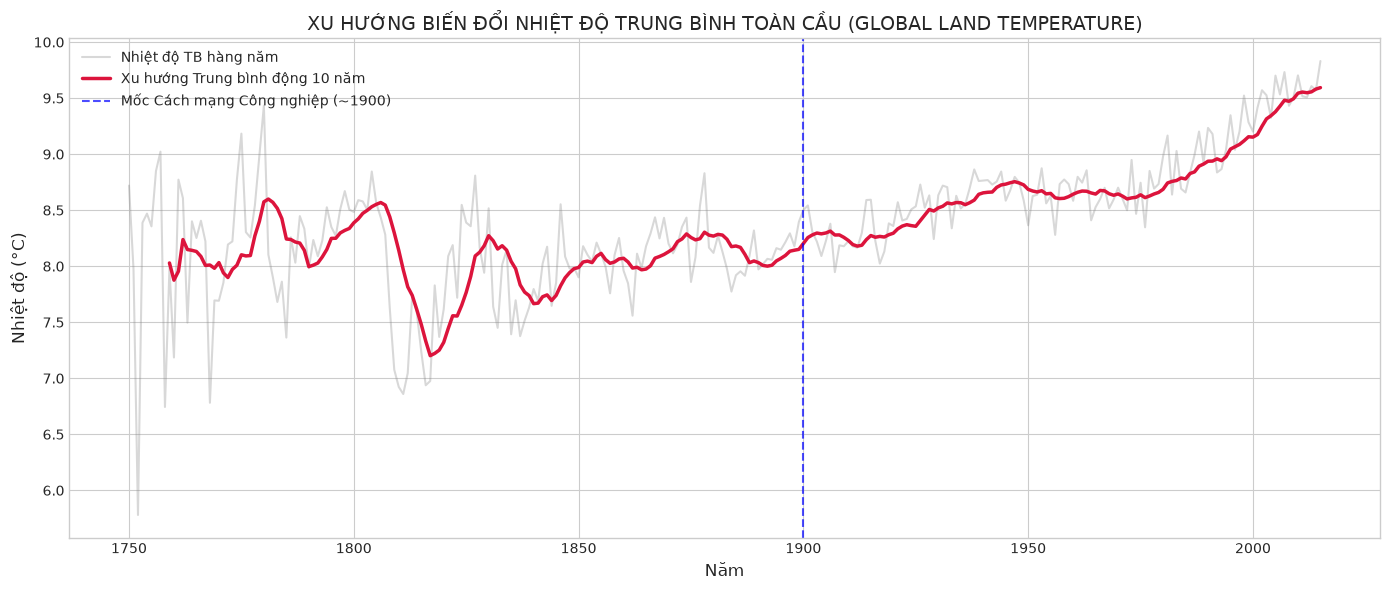

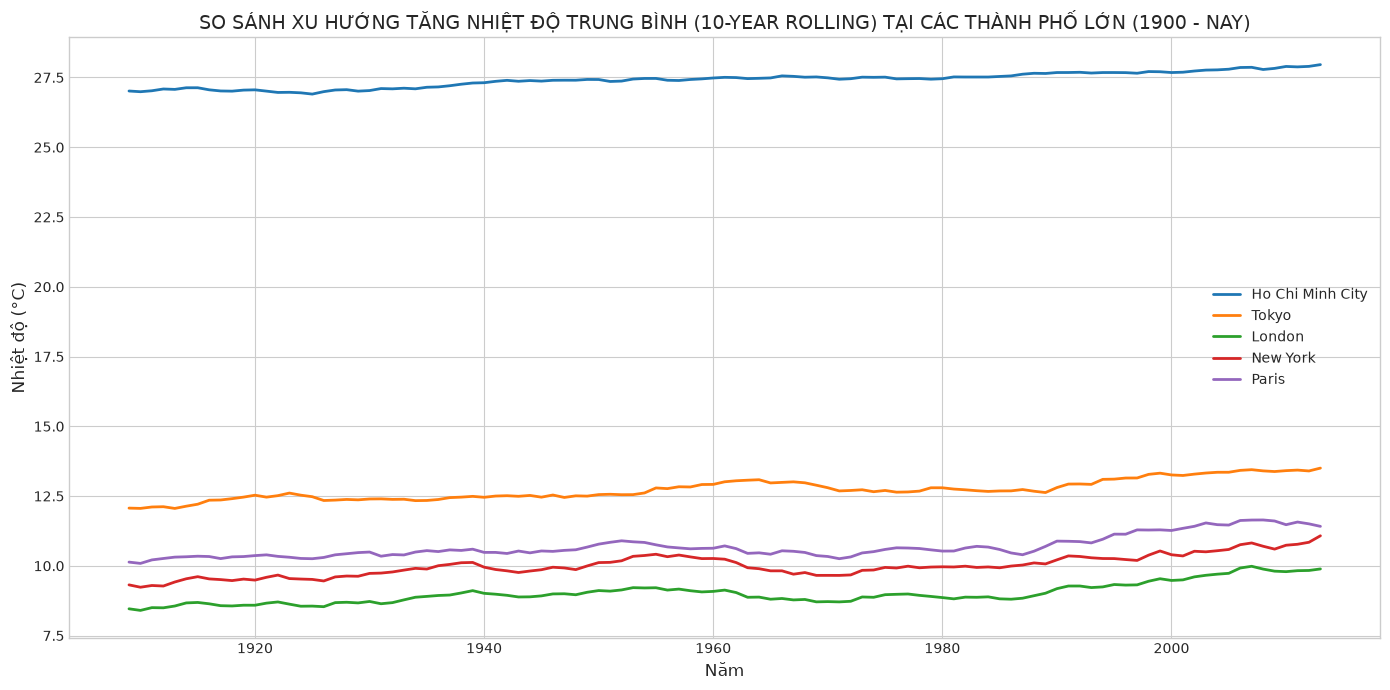

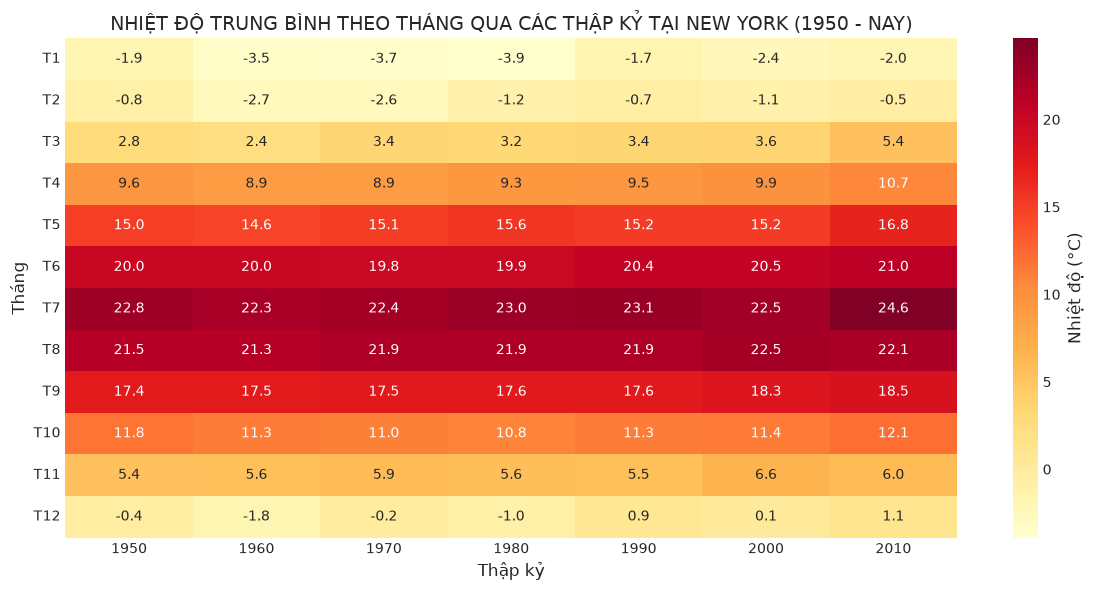

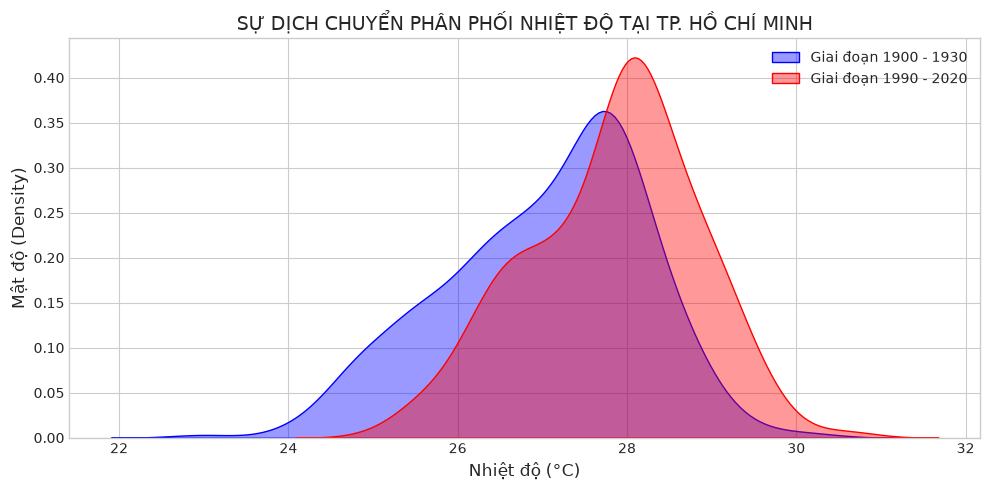


📌 TỔNG KẾT KẾT QUẢ VÀ INSIGHTS CỦA EDA:
1. GLOBAL TREND:
   - Dữ liệu cho thấy xu hướng tăng nhiệt độ rõ rệt trên toàn cầu kể từ sau năm 1900 
     (Thời điểm bắt đầu Cách mạng Công nghiệp bùng nổ).
   - Mức tăng trung bình từ 1.0°C đến 1.5°C trong 100 năm qua.

2. LOCAL TREND (Thành phố):
   - Các thành phố ở vùng ôn đới (New York, London, Paris) có độ dao động nhiệt độ giữa các tháng rất cao.
   - Các thành phố gần xích đạo (Ho Chi Minh City) có nhiệt độ cao ổn định quanh năm, 
     nhưng mức nền nhiệt chung đang tăng dần đều theo thời gian.

3. ĐỀ XUẤT CHO FEATURE ENGINEERING (File 05):
   - Cần tạo Feature: 'Lag_1', 'Lag_12' (Lấy nhiệt độ của tháng trước và cùng kỳ năm ngoái).
   - Cần tạo Feature: 'Rolling_12M_Mean', 'Rolling_60M_Mean' (Trung bình động 1 và 5 năm).
   - Cần tạo Feature: 'Decade', 'Year', 'Month' để mô hình cây (XGBoost/RandomForest) bắt được xu hướng tăng phi tuyến.
   - Cần tính chỉ số 'Anomaly' (Sự chênh lệch nhiệt độ so với trung bình lịch sử của tháng đó).



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Cấu hình phong cách biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Thư viện đã sẵn sàng!")

# Read Dữ liệu đã Clean (Từ bước 03_data_cleaning)
# Đọc file dữ liệu đã qua xử lý nội suy (Interpolation)
import pandas as pd

# 1. Đọc dữ liệu thành phố

df_city = pd.read_csv(
    r"../data/process/city_temp_cleaned.csv"
)

# 2. Đọc dữ liệu toàn cầu (chú ý đổi tên file ở cuối đường dẫn)
df_global = pd.read_csv(
    r"../data/process/global_temp_cleaned.csv"
)

# Kiểm tra thử dữ liệu
print(df_city.head())
print(df_global.head())
# Chuyển đổi cột dt sang định dạng datetime
df_city['dt'] = pd.to_datetime(df_city['dt'])
df_global['dt'] = pd.to_datetime(df_global['dt'])

# Trích xuất thêm các cột Thời gian để dễ nhóm
df_city['Year'] = df_city['dt'].dt.year
df_city['Month'] = df_city['dt'].dt.month

df_global['Year'] = df_global['dt'].dt.year
df_global['Month'] = df_global['dt'].dt.month

print("Dữ liệu City shape:", df_city.shape)
print("Dữ liệu Global shape:", df_global.shape)

#[EDA 1] Xu hướng Nhiệt độ Toàn cầu qua các Năm (Global Warming Trend)
# Gom nhóm nhiệt độ trung bình toàn cầu theo năm
global_annual = df_global.groupby('Year')['land_average_temperature'].agg(['mean', 'min', 'max']).reset_index()

# Tính đường trung bình động 10 năm (10-Year Rolling Average) để làm mịn nhiễu
global_annual['10Y_MA'] = global_annual['mean'].rolling(window=10).mean()

plt.figure(figsize=(14, 6))

# Vẽ biến động hàng năm
plt.plot(global_annual['Year'], global_annual['mean'], alpha=0.3, color='gray', label='Nhiệt độ TB hàng năm')

# Vẽ đường Trend 10 năm
plt.plot(global_annual['Year'], global_annual['10Y_MA'], color='crimson', linewidth=2.5, label='Xu hướng Trung bình động 10 năm')

plt.axvline(x=1900, color='blue', linestyle='--', alpha=0.7, label='Mốc Cách mạng Công nghiệp (~1900)')

plt.title('XU HƯỚNG BIẾN ĐỔI NHIỆT ĐỘ TRUNG BÌNH TOÀN CẦU (GLOBAL LAND TEMPERATURE)')
plt.xlabel('Năm')
plt.ylabel('Nhiệt độ (°C)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#[EDA 2] Phân tích Sự Nóng Lên tại Các Thành phố Lớn (Local Trend)
target_cities = ['Ho Chi Minh City', 'Tokyo', 'London', 'New York', 'Paris']
df_target = df_city[df_city['city'].isin(target_cities)]

# Gom nhóm theo Thành phố và Năm (Chỉ lấy dữ liệu từ năm 1900 trở đi để đảm bảo độ tin cậy)
city_annual = df_target[df_target['Year'] >= 1900].groupby(['city', 'Year'])['average_temperature'].mean().reset_index()

plt.figure(figsize=(14, 7))

for city in target_cities:
    data_c = city_annual[city_annual['city'] == city]
    # Vẽ đường trung bình động 10 năm cho từng thành phố
    data_c['10Y_MA'] = data_c['average_temperature'].rolling(window=10).mean()
    plt.plot(data_c['Year'], data_c['10Y_MA'], label=city, linewidth=2)

plt.title('SO SÁNH XU HƯỚNG TĂNG NHIỆT ĐỘ TRUNG BÌNH (10-YEAR ROLLING) TẠI CÁC THÀNH PHỐ LỚN (1900 - NAY)')
plt.xlabel('Năm')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.tight_layout()
plt.show()

#[EDA 3] Phân tích Tính Mùa Vụ & Biến đổi Khí hậu theo Tháng (Heatmap Analysis)
# Lọc dữ liệu tại 1 thành phố tiêu biểu (Ví dụ: New York - có 4 mùa rõ rệt)
ny_data = df_city[(df_city['city'] == 'New York') & (df_city['Year'] >= 1950)]

# Pivot table: Hàng là Tháng, Cột là Thập kỷ (Decade)
ny_data = ny_data.copy()
ny_data['Decade'] = (ny_data['Year'] // 10) * 10
pivot_ny = ny_data.pivot_table(index='Month', columns='Decade', values='average_temperature', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_ny, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Nhiệt độ (°C)'})

plt.title('NHIỆT ĐỘ TRUNG BÌNH THEO THÁNG QUA CÁC THẬP KỶ TẠI NEW YORK (1950 - NAY)')
plt.xlabel('Thập kỷ')
plt.ylabel('Tháng')
plt.yticks(ticks=np.arange(0.5, 12.5), labels=['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12'], rotation=0)
plt.tight_layout()
plt.show()

#[EDA 4] Phân phối & Mức độ Dội/Biến động Nhiệt độ (Distributions & Extremes)
# So sánh phân phối nhiệt độ 2 giai đoạn tại Ho Chi Minh City
hcm_data = df_city[df_city['city'] == 'Ho Chi Minh City'].copy()

period_1 = hcm_data[(hcm_data['Year'] >= 1900) & (hcm_data['Year'] <= 1930)]['average_temperature']
period_2 = hcm_data[(hcm_data['Year'] >= 1990) & (hcm_data['Year'] <= 2020)]['average_temperature']

plt.figure(figsize=(10, 5))
sns.kdeplot(period_1, shade=True, color="blue", label="Giai đoạn 1900 - 1930", alpha=0.4)
sns.kdeplot(period_2, shade=True, color="red", label="Giai đoạn 1990 - 2020", alpha=0.4)

plt.title('SỰ DỊCH CHUYỂN PHÂN PHỐI NHIỆT ĐỘ TẠI TP. HỒ CHÍ MINH')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.tight_layout()
plt.show()

#[Insights & Summary] Tổng kết Insights cho Buớc tiếp theo (Feature Engineering & ML)
print("""
================================================================================
📌 TỔNG KẾT KẾT QUẢ VÀ INSIGHTS CỦA EDA:
================================================================================
1. GLOBAL TREND:
   - Dữ liệu cho thấy xu hướng tăng nhiệt độ rõ rệt trên toàn cầu kể từ sau năm 1900 
     (Thời điểm bắt đầu Cách mạng Công nghiệp bùng nổ).
   - Mức tăng trung bình từ 1.0°C đến 1.5°C trong 100 năm qua.

2. LOCAL TREND (Thành phố):
   - Các thành phố ở vùng ôn đới (New York, London, Paris) có độ dao động nhiệt độ giữa các tháng rất cao.
   - Các thành phố gần xích đạo (Ho Chi Minh City) có nhiệt độ cao ổn định quanh năm, 
     nhưng mức nền nhiệt chung đang tăng dần đều theo thời gian.

3. ĐỀ XUẤT CHO FEATURE ENGINEERING (File 05):
   - Cần tạo Feature: 'Lag_1', 'Lag_12' (Lấy nhiệt độ của tháng trước và cùng kỳ năm ngoái).
   - Cần tạo Feature: 'Rolling_12M_Mean', 'Rolling_60M_Mean' (Trung bình động 1 và 5 năm).
   - Cần tạo Feature: 'Decade', 'Year', 'Month' để mô hình cây (XGBoost/RandomForest) bắt được xu hướng tăng phi tuyến.
   - Cần tính chỉ số 'Anomaly' (Sự chênh lệch nhiệt độ so với trung bình lịch sử của tháng đó).
================================================================================
""")